In [24]:
# Importing essential libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]  # فقط ستون‌های مورد نیاز
df.columns = ['label', 'message']

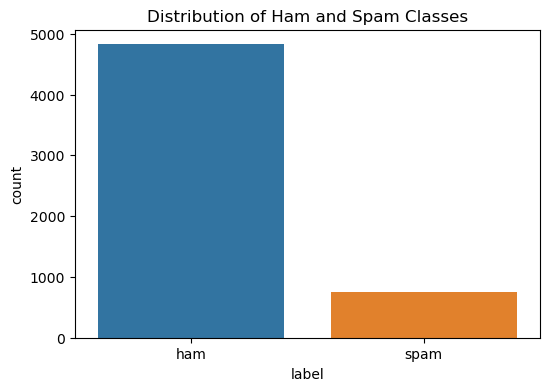

In [26]:
# Assuming df is your DataFrame and it contains a 'label' column
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Distribution of Ham and Spam Classes')
plt.show()

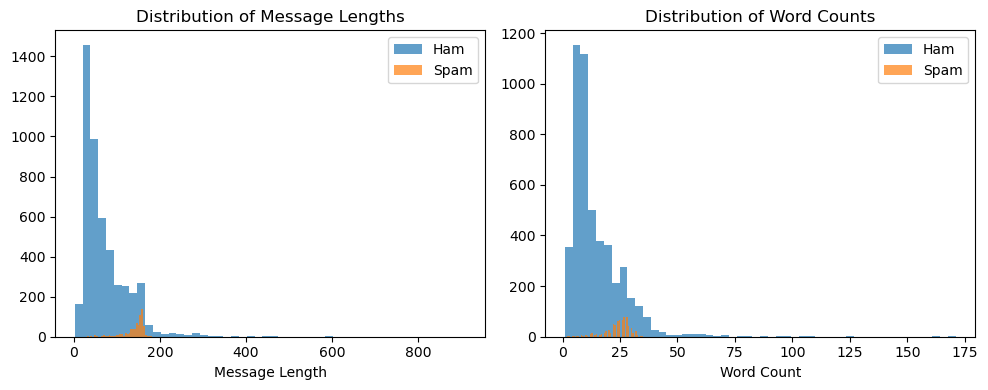

In [27]:
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))

# Subplot for message length distribution
plt.subplot(1, 2, 1)
plt.hist(df[df['label'] == 'ham']['message_length'], bins=50, alpha=0.7, label='Ham')
plt.hist(df[df['label'] == 'spam']['message_length'], bins=50, alpha=0.7, label='Spam')
plt.xlabel('Message Length')
plt.legend()
plt.title('Distribution of Message Lengths')

# Subplot for word count distribution
plt.subplot(1, 2, 2)
plt.hist(df[df['label'] == 'ham']['word_count'], bins=50, alpha=0.7, label='Ham')
plt.hist(df[df['label'] == 'spam']['word_count'], bins=50, alpha=0.7, label='Spam')
plt.xlabel('Word Count')
plt.legend()
plt.title('Distribution of Word Counts')

plt.tight_layout()
plt.show()

In [28]:
import re
from collections import Counter
# Function to clean text: remove special characters, numbers, and extra spaces
def clean_text(text):
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    return text.lower().strip()  # Convert to lowercase and strip whitespace

# Apply the clean_text function to the 'message' column
df['cleaned_message'] = df['message'].apply(clean_text)
print(df)
# Function to get the most common words in a given class
def get_top_words(label, n=10):
    text = ' '.join(df[df['label'] == label]['cleaned_message'])  # Join cleaned messages for the given label
    words = text.split()  # Split the text into words
    return Counter(words).most_common(n)  # Return the n most common words

# Print the most common words in spam messages
print("Most common words in spam messages:")
print(get_top_words('spam', 10))

# Print the most common words in ham messages
print("\nMost common words in ham messages:")
print(get_top_words('ham', 10))

     label                                            message  message_length  \
0      ham  Go until jurong point, crazy.. Available only ...             111   
1      ham                      Ok lar... Joking wif u oni...              29   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...             155   
3      ham  U dun say so early hor... U c already then say...              49   
4      ham  Nah I don't think he goes to usf, he lives aro...              61   
...    ...                                                ...             ...   
5567  spam  This is the 2nd time we have tried 2 contact u...             161   
5568   ham              Will Ì_ b going to esplanade fr home?              37   
5569   ham  Pity, * was in mood for that. So...any other s...              57   
5570   ham  The guy did some bitching but I acted like i'd...             125   
5571   ham                         Rofl. Its true to its name              26   

      word_count           

In [29]:
# List of spam keywords to check for in the messages
spam_keywords = ['free', 'win', 'winner', 'prize', 'urgent', 'claim', 'text', 'txt', 'cash', 'prize']

# Create a new column for each keyword indicating its presence (1) or absence (0)
for keyword in spam_keywords:
    df[keyword] = df['message'].str.contains(keyword, case=False, na=False).astype(int)

# Print the count of each spam keyword in the dataset
print("\nSpam Keywords in the Data:")
for keyword in spam_keywords:
    print(f"{keyword}: {df[keyword].sum()}")


Spam Keywords in the Data:
free: 265
win: 166
winner: 23
prize: 89
urgent: 69
claim: 116
text: 224
txt: 194
cash: 81
prize: 89


In [30]:
# Print a few samples of spam messages
print("\nSample Spam Messages:")
print(df[df['label'] == 'spam']['message'].head(3))

# Print a few samples of ham messages
print("\nSample Ham Messages:")
print(df[df['label'] == 'ham']['message'].head(3))


Sample Spam Messages:
2    Free entry in 2 a wkly comp to win FA Cup fina...
5    FreeMsg Hey there darling it's been 3 week's n...
8    WINNER!! As a valued network customer you have...
Name: message, dtype: object

Sample Ham Messages:
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
3    U dun say so early hor... U c already then say...
Name: message, dtype: object


In [31]:
import numpy as np

# Create several numerical features from the text
df['message_length'] = df['message'].apply(len)  # Length of the message
df['word_count'] = df['message'].apply(lambda x: len(x.split()))  # Count of words in the message
df['char_count'] = df['message'].apply(lambda x: len(x.replace(" ", "")))  # Count of characters excluding spaces
df['avg_word_length'] = df['message'].apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)  # Average word length
df['exclamation_count'] = df['message'].apply(lambda x: x.count('!'))  # Count of exclamation marks
df['question_count'] = df['message'].apply(lambda x: x.count('?'))  # Count of question marks
df['digit_count'] = df['message'].apply(lambda x: sum(c.isdigit() for c in x))  # Count of digits
df['has_free'] = df['message'].str.contains('free', case=False, na=False).astype(int)  # Presence of the word 'free'
df['has_win'] = df['message'].str.contains('win', case=False, na=False).astype(int)  # Presence of the word 'win'
df['has_urgent'] = df['message'].str.contains('urgent', case=False, na=False).astype(int)  # Presence of the word 'urgent'
df['has_call'] = df['message'].str.contains('call', case=False, na=False).astype(int)  # Presence of the word 'call'

In [32]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

In [33]:
print("Available columns after adding 'label_num':")
print(df.columns)


Available columns after adding 'label_num':
Index(['label', 'message', 'message_length', 'word_count', 'cleaned_message',
       'free', 'win', 'winner', 'prize', 'urgent', 'claim', 'text', 'txt',
       'cash', 'char_count', 'avg_word_length', 'exclamation_count',
       'question_count', 'digit_count', 'has_free', 'has_win', 'has_urgent',
       'has_call', 'label_num'],
      dtype='object')


In [34]:
# Select numeric columns for correlation calculation
numeric_cols = [
    'label_num',           # Numeric representation of the label (spam or ham)
    'message_length',      # Length of the message
    'word_count',          # Count of words in the message
    'char_count',          # Count of characters excluding spaces
    'avg_word_length',     # Average length of words in the message
    'exclamation_count',    # Count of exclamation marks
    'question_count',      # Count of question marks
    'digit_count',         # Count of digits
    'has_free',            # Presence of the word 'free'
    'has_win',             # Presence of the word 'win'
    'has_urgent',          # Presence of the word 'urgent'
    'has_call'             # Presence of the word 'call'
]

# Compute the correlation matrix
correlation_matrix = df[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                   label_num  message_length  word_count  char_count  \
label_num           1.000000        0.387285    0.290263    0.408325   
message_length      0.387285        1.000000    0.973725    0.998600   
word_count          0.290263        0.973725    1.000000    0.960539   
char_count          0.408325        0.998600    0.960539    1.000000   
avg_word_length     0.241314        0.082962   -0.069860    0.117808   
exclamation_count   0.275985        0.270618    0.251473    0.273629   
question_count     -0.026704        0.102405    0.134036    0.094540   
digit_count         0.843589        0.391906    0.294438    0.412696   
has_free            0.404577        0.209047    0.182143    0.214122   
has_win             0.240872        0.149207    0.127841    0.153593   
has_urgent          0.251245        0.117835    0.075621    0.127112   
has_call            0.434080        0.224630    0.171504    0.235910   

                   avg_word_length  exclama

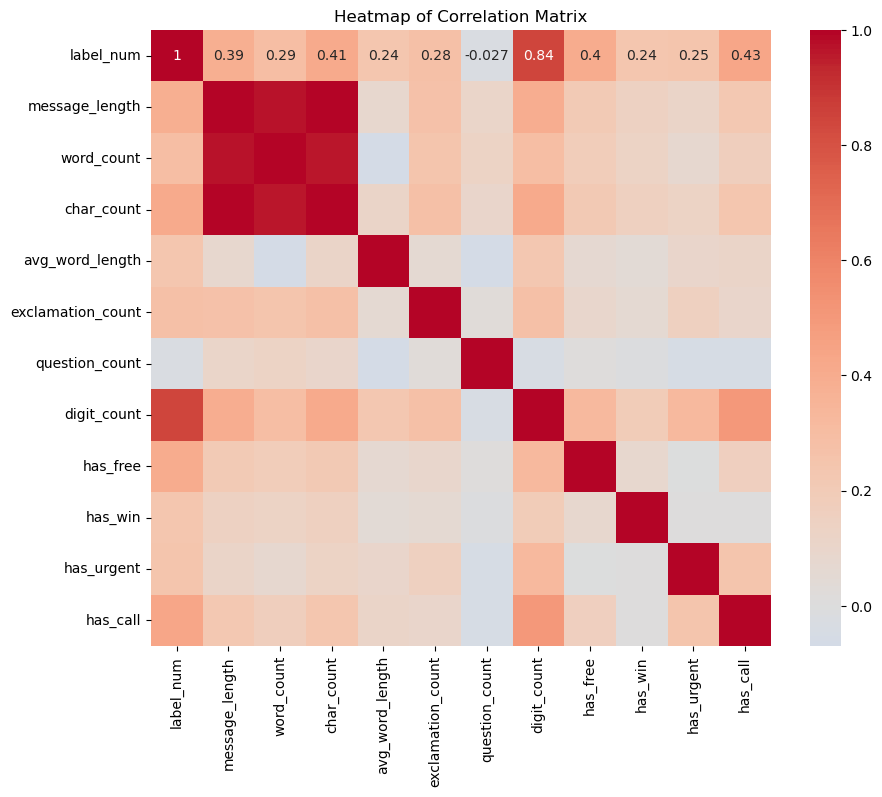

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap of Correlation Matrix')
plt.show()

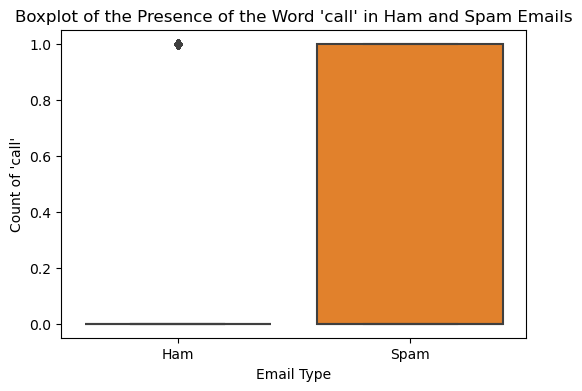

In [36]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="label", y="has_call", data=df)
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.title("Boxplot of the Presence of the Word 'call' in Ham and Spam Emails")
plt.ylabel("Count of 'call'")
plt.xlabel("Email Type")
plt.show()

In [37]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate mean of each numeric feature for Spam vs Ham
spam_means = df[df['label_num'] == 1][numeric_cols].mean()
ham_means = df[df['label_num'] == 0][numeric_cols].mean()

# Difference between Spam and Ham
feature_diff = (spam_means - ham_means).abs().sort_values(ascending=False)

# Show top 10 features
print(feature_diff.head(10))

message_length       67.842504
char_count           58.273537
digit_count          15.459762
word_count            9.650784
label_num             1.000000
avg_word_length       0.815265
exclamation_count     0.551683
has_call              0.404836
free                  0.252720
has_free              0.252720
dtype: float64


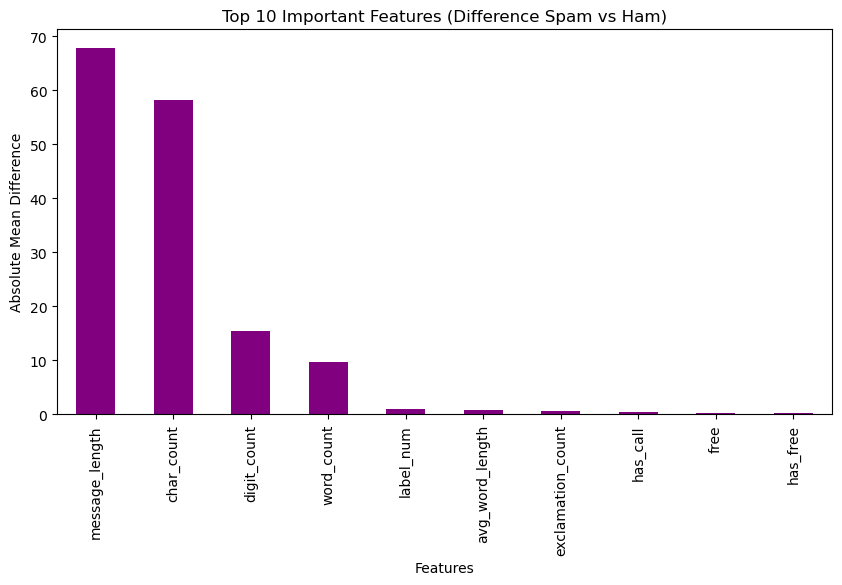

In [38]:
# Bar plot of top 10 important features
plt.figure(figsize=(10,5))
feature_diff.head(10).plot(kind='bar', color="purple")
plt.title("Top 10 Important Features (Difference Spam vs Ham)")
plt.ylabel("Absolute Mean Difference")
plt.xlabel("Features")
plt.show()

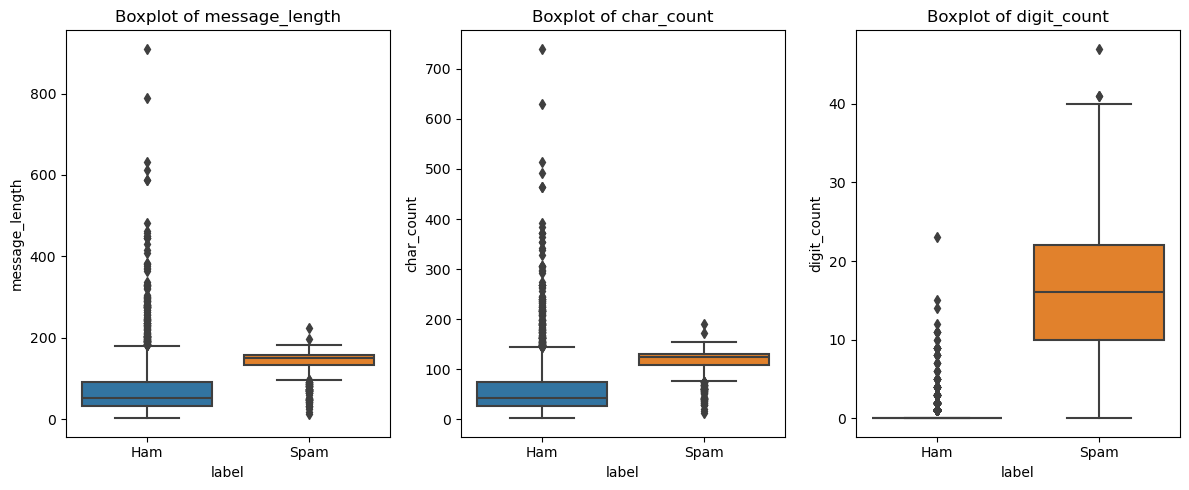

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already have `feature_diff` calculated and `important_features` defined
important_features = feature_diff.head(3).index  # Get the top 3 important features

plt.figure(figsize=(12, 5))
for i, feat in enumerate(important_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x="label", y=feat, data=df)  # Ensure you use the correct DataFrame
    plt.xticks([0, 1], ['Ham', 'Spam'])
    plt.title(f"Boxplot of {feat}")
plt.tight_layout()
plt.show()

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# 
# Split data into features (X) and labels (y)
X = df['message']  # replace 'message' with 'text' if that's the correct column name
y = df['label_num']  # use 'label_num' if you encoded it previously

# Vectorize the text
vectorizer = CountVectorizer(stop_words='english')
X_vectors = vectorizer.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_vectors, y, test_size=0.2, random_state=42
)

# Output the shapes of the resulting datasets
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

Training data shape: (4457, 8404), Training labels shape: (4457,)
Testing data shape: (1115, 8404), Testing labels shape: (1115,)


In [41]:
from sklearn.naive_bayes import MultinomialNB

# ایجاد مدل
nb_model = MultinomialNB()

# آموزش مدل روی داده‌های آموزشی
nb_model.fit(X_train, y_train)

MultinomialNB()

In [42]:


# Make predictions on the test set
y_pred = nb_model.predict(X_test)


Accuracy: 0.9802690582959641


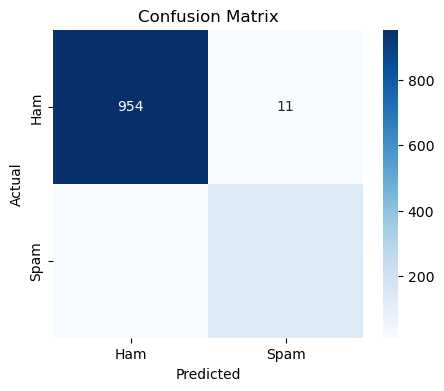

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       965
        Spam       0.93      0.93      0.93       150

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report


# Use TF-IDF to convert text to vectors
tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)


In [45]:

# Create and train the Naive Bayes model
nb_model_tfidf = MultinomialNB()
nb_model_tfidf.fit(X_train, y_train)


MultinomialNB()

In [46]:

# Make predictions on the test set
y_pred_tfidf = nb_model_tfidf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_tfidf)
report = classification_report(y_test, y_pred_tfidf, target_names=["Ham", "Spam"])

# Print evaluation metrics
print("Accuracy (TF-IDF):", accuracy)
print("Classification Report:")
print(report)

Accuracy (TF-IDF): 0.968609865470852
Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       965
        Spam       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [47]:
# Calculate the number of uppercase letters in the 'message' column of the DataFrame 'data'
df['uppercase_count'] = df['message'].apply(lambda x: sum(1 for c in x if c.isupper()))

# Calculate the length of the 'message' column
df['email_length'] = df['message'].apply(len)  # Add this line

# Select specific features: 'email_length', 'uppercase_count', and 'label' from the DataFrame
features_corr = df[['email_length', 'uppercase_count', 'label_num']]

# Compute the correlation matrix for the selected features
corr_matrix = features_corr.corr()

# Print the resulting correlation matrix
print(corr_matrix)

                 email_length  uppercase_count  label_num
email_length         1.000000         0.386407   0.387285
uppercase_count      0.386407         1.000000   0.349197
label_num            0.387285         0.349197   1.000000


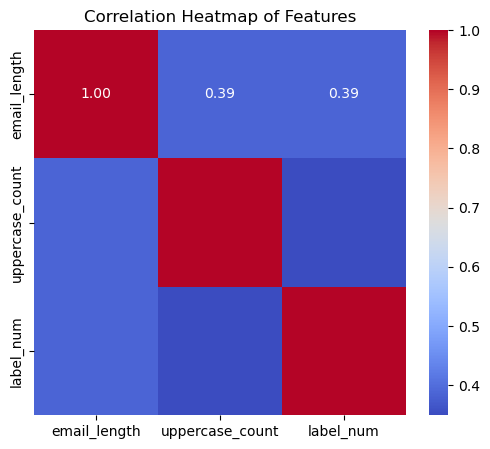

In [49]:

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

In [51]:
from scipy.sparse import hstack
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Selecting numeric features
numeric_features = df[['email_length', 'uppercase_count', 
                       'exclamation_count', 'digit_count',
                       'has_free', 'has_win', 'has_urgent', 'has_call']]

# Converting numeric features to sparse matrix for compatibility with TF-IDF
numeric_sparse = sparse.csr_matrix(numeric_features.values)

# Combining text features (TF-IDF) with numeric features
X_combined = hstack([X_tfidf, numeric_sparse])

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

# Training the Naive Bayes model
nb_model_combined = MultinomialNB()
nb_model_combined.fit(X_train, y_train)

# Prediction
y_pred_combined = nb_model_combined.predict(X_test)

# Evaluation
print("Accuracy (Hybrid Model):", accuracy_score(y_test, y_pred_combined))
print(classification_report(y_test, y_pred_combined, target_names=["Ham", "Spam"]))

Accuracy (Hybrid Model): 0.9632286995515695
              precision    recall  f1-score   support

         Ham       0.98      0.97      0.98       965
        Spam       0.84      0.89      0.87       150

    accuracy                           0.96      1115
   macro avg       0.91      0.93      0.92      1115
weighted avg       0.96      0.96      0.96      1115

